In [4]:
import pandas as pd

# Paths for silhouette dataset
sil_train_path = r"D:/Fyp_project_root/data/bodym-dataset/train/measurements.csv"
sil_testA_path = r"D:/Fyp_project_root/data/bodym-dataset/testA/measurements.csv"
sil_testB_path = r"D:/Fyp_project_root/data/bodym-dataset/testB/measurements.csv"

# Load them
df_sil_train = pd.read_csv(sil_train_path)
df_sil_testA = pd.read_csv(sil_testA_path)
df_sil_testB = pd.read_csv(sil_testB_path)

# Merge into one silhouette dataset
df_sil = pd.concat([df_sil_train, df_sil_testA, df_sil_testB], ignore_index=True)

print("Silhouette dataset loaded.")
print("Silhouette columns:")
print(df_sil.columns)
print("\nSample rows from silhouette data:")
print(df_sil.head())
df_sil['height'].head()



Silhouette dataset loaded.
Silhouette columns:
Index(['subject_id', 'ankle', 'arm-length', 'bicep', 'calf', 'chest',
       'forearm', 'height', 'hip', 'leg-length', 'shoulder-breadth',
       'shoulder-to-crotch', 'thigh', 'waist', 'wrist'],
      dtype='object')

Sample rows from silhouette data:
                                    subject_id      ankle  arm-length  \
0  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg  24.343954   52.902378   
1  -5OHO2b5mRDY1rvAf07sYYtekEEX7ViEGmvRr7l4tfc  22.001783   46.763233   
2  -5iHTazqnmWBsnUY6ymoCw1kORMymRDaUla1eNOjgvI  26.565006   53.288597   
3  -60o95b9oEE83BDV3GpsAVPA4TFvxuPPqtXEY5PApy8  24.779566   49.077751   
4  -67TrwlJ3GSsqPeHaa2Nb0iQ-BKZfIx4ERysQPZ0-SY  20.788853   42.229557   

       bicep       calf       chest    forearm      height         hip  \
0  33.294395  38.709511  102.526024  27.599094  177.610992  108.047134   
1  28.288971  35.649963   99.253395  24.813375  164.379623   92.128685   
2  30.800959  39.854950  102.391273  27

0    177.610992
1    164.379623
2    183.718842
3    169.059113
4    146.516632
Name: height, dtype: float64

In [5]:
print("\nMissing values in silhouette:")
print(df_sil.isnull().sum())


Missing values in silhouette:
subject_id            0
ankle                 0
arm-length            0
bicep                 0
calf                  0
chest                 0
forearm               0
height                0
hip                   0
leg-length            0
shoulder-breadth      0
shoulder-to-crotch    0
thigh                 0
waist                 0
wrist                 0
dtype: int64


In [6]:
import pandas as pd

# Load all silhouette data (train + testA + testB)
sil_train = pd.read_csv("D:/Fyp_project_root/data/bodym-dataset/train/measurements.csv")
sil_testA = pd.read_csv("D:/Fyp_project_root/data/bodym-dataset/testA/measurements.csv")
sil_testB = pd.read_csv("D:/Fyp_project_root/data/bodym-dataset/testB/measurements.csv")

meta_train = pd.read_csv("D:/Fyp_project_root/data/bodym-dataset/train/hwg_metadata.csv")
meta_testA = pd.read_csv("D:/Fyp_project_root/data/bodym-dataset/testA/hwg_metadata.csv")
meta_testB = pd.read_csv("D:/Fyp_project_root/data/bodym-dataset/testB/hwg_metadata.csv")

# Merge all measurements together
df_sil_measure = pd.concat([sil_train, sil_testA, sil_testB], ignore_index=True)

# Merge all metadata together
df_sil_meta = pd.concat([meta_train, meta_testA, meta_testB], ignore_index=True)

# Now merge measurements with metadata on subject_id
df_sil = pd.merge(df_sil_measure, df_sil_meta, on="subject_id")

print(df_sil.head())
print(df_sil.columns)


                                    subject_id      ankle  arm-length  \
0  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg  24.343954   52.902378   
1  -5OHO2b5mRDY1rvAf07sYYtekEEX7ViEGmvRr7l4tfc  22.001783   46.763233   
2  -5iHTazqnmWBsnUY6ymoCw1kORMymRDaUla1eNOjgvI  26.565006   53.288597   
3  -60o95b9oEE83BDV3GpsAVPA4TFvxuPPqtXEY5PApy8  24.779566   49.077751   
4  -67TrwlJ3GSsqPeHaa2Nb0iQ-BKZfIx4ERysQPZ0-SY  20.788853   42.229557   

       bicep       calf       chest    forearm      height         hip  \
0  33.294395  38.709511  102.526024  27.599094  177.610992  108.047134   
1  28.288971  35.649963   99.253395  24.813375  164.379623   92.128685   
2  30.800959  39.854950  102.391273  27.719795  183.718842  106.044121   
3  34.613113  38.104267  111.164070  28.550409  169.059113  109.529465   
4  24.527142  29.181356   93.627777  21.979038  146.516632   87.134102   

   leg-length  shoulder-breadth  shoulder-to-crotch      thigh       waist  \
0   81.736435         35.915691       

In [7]:
# Convert height from cm to meters
df_sil["height_m"] = df_sil["height_cm"] / 100

# Compute BMI
df_sil["bmi"] = df_sil["weight_kg"] / (df_sil["height_m"] ** 2)

print(df_sil[["subject_id", "height_cm", "weight_kg", "bmi"]].head())


                                    subject_id  height_cm  weight_kg  \
0  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg      178.0       79.6   
1  -5OHO2b5mRDY1rvAf07sYYtekEEX7ViEGmvRr7l4tfc      163.0       65.0   
2  -5iHTazqnmWBsnUY6ymoCw1kORMymRDaUla1eNOjgvI      185.0       82.9   
3  -60o95b9oEE83BDV3GpsAVPA4TFvxuPPqtXEY5PApy8      166.0       88.7   
4  -67TrwlJ3GSsqPeHaa2Nb0iQ-BKZfIx4ERysQPZ0-SY      144.6       44.2   

         bmi  
0  25.123091  
1  24.464602  
2  24.222060  
3  32.188997  
4  21.139061  


In [8]:
df_sil[["subject_id", "height_cm", "weight_kg", "bmi"]].head()


,subject_id,height_cm,weight_kg,bmi
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,178.0,79.6,25.123091
1,-5OHO2b5mRDY1rvAf07sYYtekEEX7ViEGmvRr7l4tfc,163.0,65.0,24.464602
2,-5iHTazqnmWBsnUY6ymoCw1kORMymRDaUla1eNOjgvI,185.0,82.9,24.222060
3,-60o95b9oEE83BDV3GpsAVPA4TFvxuPPqtXEY5PApy8,166.0,88.7,32.188997
4,-67TrwlJ3GSsqPeHaa2Nb0iQ-BKZfIx4ERysQPZ0-SY,144.6,44.2,21.139061


Exploratory Data Analysis (EDA)

In [9]:
df_sil[["height_cm", "weight_kg", "bmi"]].describe()


,height_cm,weight_kg,bmi
count,2507.000000,2507.000000,2507.000000
mean,170.570226,74.279803,25.416270
std,9.482867,16.898214,4.952345
min,141.000000,28.700000,10.618869
25%,163.825000,62.100000,22.152356
50%,170.750000,72.500000,24.615150
75%,177.500000,83.950000,27.506728
max,197.500000,184.500000,62.809813


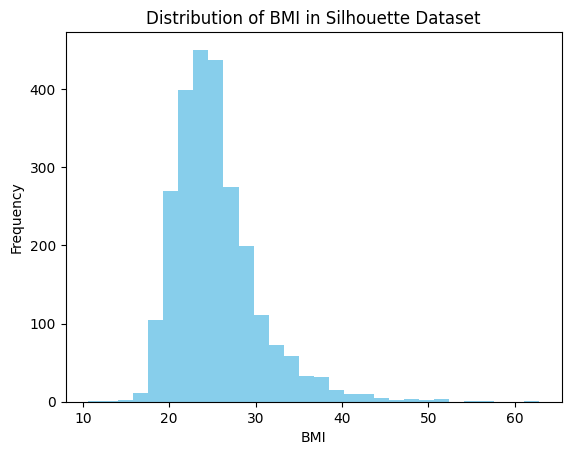

In [10]:
import matplotlib.pyplot as plt

plt.hist(df_sil["bmi"], bins=30, color="skyblue")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("Distribution of BMI in Silhouette Dataset")
plt.show()


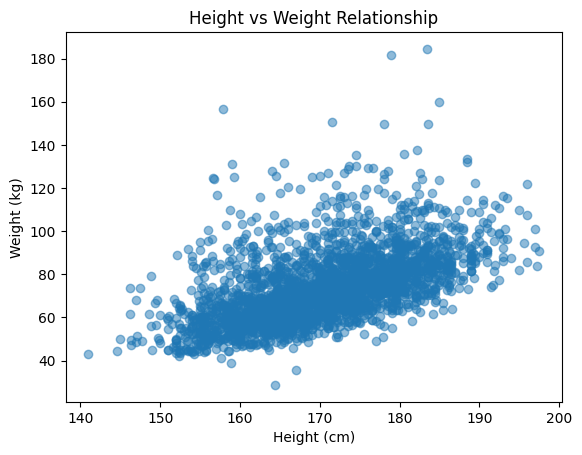

In [11]:
plt.scatter(df_sil["height_cm"], df_sil["weight_kg"], alpha=0.5)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight Relationship")
plt.show()


In [12]:
print(df_sil[df_sil["bmi"] > 50])  # extremely high BMI
print(df_sil[df_sil["bmi"] < 10])  # extremely low BMI


                                       subject_id      ankle  arm-length  \
180                      59bc2758681516389ccf4071  25.614805   47.604340   
183                      59bc275a681516389ccf40d8  24.929155   45.724220   
192                      59bc275c681516389ccf41bf  30.937994   45.623104   
307   6DyKMxQrUO8OJstSulWISLqB6oXt3KWHnwMacXGfiDc  26.061012   46.273323   
1039  TszWqWftIyEOXwJ4495NROUPn2ui88j8RdJrMy5eFKk  30.831259   48.837036   
1172  Xgshyw2K_FeeM3GNCyfoS5pJoTNIfEGMf1qKQxiO5YU  30.857607   50.282497   
1345  be8CgGUva4wFWAGzIJyfHXyYyZxcVMUK9IXmJ90JEug  32.977467   50.814266   

          bicep       calf       chest    forearm      height         hip  \
180   45.069130  44.946823  148.795853  31.643528  163.993790  145.555099   
183   46.473225  41.680626  139.537704  31.900314  157.487045  149.450073   
192   55.813061  45.407982  153.940750  39.747761  162.549133  158.517914   
307   42.813435  42.183403  136.150513  31.436712  158.811676  145.231323   
1039  

In [13]:
from sklearn.model_selection import train_test_split

# Get unique subjects
subjects = df_sil["subject_id"].unique()

# Step 1: Train/Test split on subjects
train_subj, test_subj = train_test_split(
    subjects, test_size=0.15, random_state=42
)

# Step 2: Train subjects further split into train/val
train_subj, val_subj = train_test_split(
    train_subj, test_size=0.176, random_state=42
)
# Why 0.176? Because:
# 0.85 * 0.176 ≈ 0.15 ⇒ validation = 15%

# Now create the actual dataframes
df_train = df_sil[df_sil["subject_id"].isin(train_subj)]
df_val   = df_sil[df_sil["subject_id"].isin(val_subj)]
df_test  = df_sil[df_sil["subject_id"].isin(test_subj)]

# Print sizes
print("Train:", len(df_train))
print("Val:", len(df_val))
print("Test:", len(df_test))


Train: 1756
Val: 375
Test: 376


In [14]:
import pandas as pd

paths = [
    "D:/Fyp_project_root/data/bodym-dataset/train/measurements.csv",
    "D:/Fyp_project_root/data/bodym-dataset/testA/measurements.csv",
    "D:/Fyp_project_root/data/bodym-dataset/testB/measurements.csv",
]

for p in paths:
    df = pd.read_csv(p)
    print(p, " → ", len(df))


D:/Fyp_project_root/data/bodym-dataset/train/measurements.csv  →  2018
D:/Fyp_project_root/data/bodym-dataset/testA/measurements.csv  →  87
D:/Fyp_project_root/data/bodym-dataset/testB/measurements.csv  →  400


In [15]:
paths_meta = [
    "D:/Fyp_project_root/data/bodym-dataset/train/hwg_metadata.csv",
    "D:/Fyp_project_root/data/bodym-dataset/testA/hwg_metadata.csv",
    "D:/Fyp_project_root/data/bodym-dataset/testB/hwg_metadata.csv",
]

for p in paths_meta:
    df = pd.read_csv(p)
    print(p, " → ", len(df))


D:/Fyp_project_root/data/bodym-dataset/train/hwg_metadata.csv  →  2018
D:/Fyp_project_root/data/bodym-dataset/testA/hwg_metadata.csv  →  87
D:/Fyp_project_root/data/bodym-dataset/testB/hwg_metadata.csv  →  400


In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

preds = rf.predict(X_val)

mae  = mean_absolute_error(y_val, preds)
mse  = mean_squared_error(y_val, preds)      # always available
rmse = np.sqrt(mse)                          # compute RMSE manually

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)


Validation MAE: 0.6901006030955392
Validation RMSE: 1.2120400532321902


In [18]:
import sklearn; print(sklearn.__version__)


1.7.1


               feature  importance
7                  hip    0.512143
4                chest    0.193459
12               waist    0.161692
11               thigh    0.040569
2                bicep    0.030318
8           leg-length    0.020199
14           height_cm    0.011622
1           arm-length    0.005990
5              forearm    0.004504
3                 calf    0.004463
6               height    0.004087
0                ankle    0.003975
13               wrist    0.003050
9     shoulder-breadth    0.002036
10  shoulder-to-crotch    0.001894


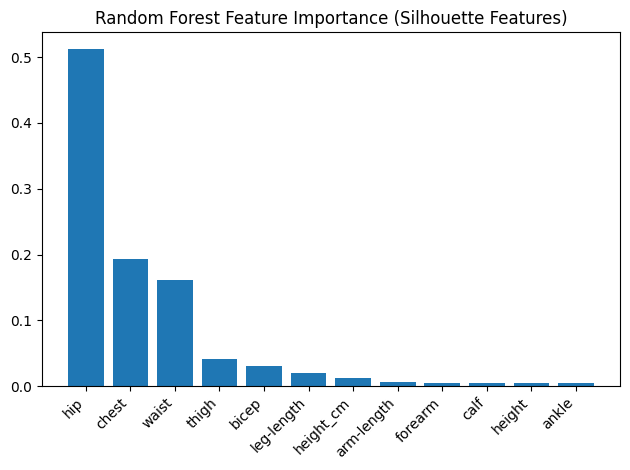

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
fi = pd.DataFrame({"feature": feature_cols, "importance": importances}) \
        .sort_values("importance", ascending=False)

print(fi.head(15))

# Bar chart of top features
top_k = 12
plt.bar(range(top_k), fi["importance"].values[:top_k])
plt.xticks(range(top_k), fi["feature"].values[:top_k], rotation=45, ha="right")
plt.title("Random Forest Feature Importance (Silhouette Features)")
plt.tight_layout()
plt.show()


In [22]:
import cv2
import os

img_path = "D:/Fyp_project_root/data/bodym-dataset/train/mask/00a19f879a88dafab8af4eabbfef045a.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

print("Shape:", img.shape)


Shape: (960, 720)


In [25]:
import os

# All folders to search for silhouettes
mask_dirs = [
    "D:/Fyp_project_root/data/bodym-dataset/train/mask",
    "D:/Fyp_project_root/data/bodym-dataset/testA/mask",
    "D:/Fyp_project_root/data/bodym-dataset/testB/mask"
]

def find_image(subject_id):
    fname = subject_id + ".png"
    for d in mask_dirs:
        path = os.path.join(d, fname)
        if os.path.exists(path):
            return path
    return None


In [26]:
df_train["img_path"] = df_train["subject_id"].apply(find_image)
df_val["img_path"]   = df_val["subject_id"].apply(find_image)
df_test["img_path"]  = df_test["subject_id"].apply(find_image)


C:\Users\tayya\AppData\Local\Temp\ipykernel_6096\470118986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["img_path"] = df_train["subject_id"].apply(find_image)
C:\Users\tayya\AppData\Local\Temp\ipykernel_6096\470118986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val["img_path"]   = df_val["subject_id"].apply(find_image)
C:\Users\tayya\AppData\Local\Temp\ipykernel_6096\470118986.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [27]:
print("Missing in train:", df_train["img_path"].isna().sum())
print("Missing in val:", df_val["img_path"].isna().sum())
print("Missing in test:", df_test["img_path"].isna().sum())


Missing in train: 1756
Missing in val: 375
Missing in test: 376


In [28]:
import os

folder = "D:/Fyp_project_root/data/bodym-dataset/train/mask"
files = os.listdir(folder)

print("Sample image filenames:")
for f in files[:10]:
    print(f)


Sample image filenames:
001f3a88501980a5eca6f6346a0ca8d9.png
0023f967e5089c95ae22c43e25b2cef1.png
0026b236ae6f63db9c354cc2916c9c34.png
003d4db18f3359c8ed8410817b726539.png
004c72a4efa6341764e10e6f599d4212.png
005e8eca196e8127de2fa342ccf6a007.png
006269330d4250ea76578c935d09b700.png
0063d101686814661ad13e8b71e7a20f.png
007e27ae1b23ff14d51cf4fcd2a308e5.png
007ec205cc5dd598e68659994b7fc508.png


In [29]:
print("Total images in mask:", len(files))


Total images in mask: 6134


In [30]:
print(df_sil["subject_id"].head())


0    -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg
1    -5OHO2b5mRDY1rvAf07sYYtekEEX7ViEGmvRr7l4tfc
2    -5iHTazqnmWBsnUY6ymoCw1kORMymRDaUla1eNOjgvI
3    -60o95b9oEE83BDV3GpsAVPA4TFvxuPPqtXEY5PApy8
4    -67TrwlJ3GSsqPeHaa2Nb0iQ-BKZfIx4ERysQPZ0-SY
Name: subject_id, dtype: object


In [34]:
import pandas as pd

map_path = r"D:/Fyp_project_root/data/bodym-dataset/train/subject_to_photo_map.csv"
df_map = pd.read_csv(map_path)

print(df_map.head())
print(df_map.columns)
print(df_map.shape)
df_map.head()
df_map.columns



                                    subject_id  \
0  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   
1  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   
2  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   
3  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   
4  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg   

                           photo_id  
0  e6f404ebda41ebe93573d3e219c88297  
1  39a4241cb892618a694747e224d57b9e  
2  a00a6c0c074efbd92c894cbc77023939  
3  7c99b3017f21f9797851e70de084bfcb  
4  3000cb26b2090db5a7d82926af8c6a83  
Index(['subject_id', 'photo_id'], dtype='object')
(6134, 2)


Index(['subject_id', 'photo_id'], dtype='object')

In [35]:
df_full = df_sil.merge(df_map, on="subject_id", how="inner")

print(df_full.shape)
print(df_full.head())


(6134, 21)
                                    subject_id      ankle  arm-length  \
0  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg  24.343954   52.902378   
1  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg  24.343954   52.902378   
2  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg  24.343954   52.902378   
3  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg  24.343954   52.902378   
4  -494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg  24.343954   52.902378   

       bicep       calf       chest    forearm      height         hip  \
0  33.294395  38.709511  102.526024  27.599094  177.610992  108.047134   
1  33.294395  38.709511  102.526024  27.599094  177.610992  108.047134   
2  33.294395  38.709511  102.526024  27.599094  177.610992  108.047134   
3  33.294395  38.709511  102.526024  27.599094  177.610992  108.047134   
4  33.294395  38.709511  102.526024  27.599094  177.610992  108.047134   

   leg-length  ...  shoulder-to-crotch      thigh      waist      wrist  \
0   81.736435  ...           6

In [36]:
def get_mask_path(photo_id):
    return f"D:/Fyp_project_root/data/bodym-dataset/train/mask/{photo_id}.png"

df_full["img_path"] = df_full["photo_id"].apply(get_mask_path)


In [37]:
import os

df_full["exists"] = df_full["img_path"].apply(os.path.exists)
print(df_full["exists"].value_counts())


exists
True    6134
Name: count, dtype: int64


In [38]:
print(df_full.shape)
print(df_full.columns)
df_full.head()


(6134, 23)
Index(['subject_id', 'ankle', 'arm-length', 'bicep', 'calf', 'chest',
       'forearm', 'height', 'hip', 'leg-length', 'shoulder-breadth',
       'shoulder-to-crotch', 'thigh', 'waist', 'wrist', 'gender', 'height_cm',
       'weight_kg', 'height_m', 'bmi', 'photo_id', 'img_path', 'exists'],
      dtype='object')


,subject_id,ankle,arm-length,bicep,calf,chest,forearm,height,hip,leg-length,...,waist,wrist,gender,height_cm,weight_kg,height_m,bmi,photo_id,img_path,exists
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,e6f404ebda41ebe93573d3e219c88297,D:/Fyp_project_root/data/bodym-dataset/train/m...,True
1,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,39a4241cb892618a694747e224d57b9e,D:/Fyp_project_root/data/bodym-dataset/train/m...,True
2,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,a00a6c0c074efbd92c894cbc77023939,D:/Fyp_project_root/data/bodym-dataset/train/m...,True
3,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,7c99b3017f21f9797851e70de084bfcb,D:/Fyp_project_root/data/bodym-dataset/train/m...,True
4,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,92.286171,16.709131,male,178.0,79.6,1.78,25.123091,3000cb26b2090db5a7d82926af8c6a83,D:/Fyp_project_root/data/bodym-dataset/train/m...,True


In [39]:
from sklearn.model_selection import train_test_split

subjects = df_full["subject_id"].unique()

# 70% train, 15% val, 15% test
sub_train, sub_temp = train_test_split(subjects, test_size=0.30, random_state=42)
sub_val, sub_test = train_test_split(sub_temp, test_size=0.50, random_state=42)

len(sub_train), len(sub_val), len(sub_test)


(1412, 303, 303)

In [40]:
df_full["split"] = df_full["subject_id"].apply(
    lambda x: "train" if x in sub_train else
              "val"   if x in sub_val else
              "test"
)


In [42]:
df_full.shape
df_full.columns
df_full["split"].value_counts()


split
train    4316
test      959
val       859
Name: count, dtype: int64

In [43]:
df_full.columns
df_full.head()


,subject_id,ankle,arm-length,bicep,calf,chest,forearm,height,hip,leg-length,...,wrist,gender,height_cm,weight_kg,height_m,bmi,photo_id,img_path,exists,split
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,16.709131,male,178.0,79.6,1.78,25.123091,e6f404ebda41ebe93573d3e219c88297,D:/Fyp_project_root/data/bodym-dataset/train/m...,True,train
1,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,16.709131,male,178.0,79.6,1.78,25.123091,39a4241cb892618a694747e224d57b9e,D:/Fyp_project_root/data/bodym-dataset/train/m...,True,train
2,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,16.709131,male,178.0,79.6,1.78,25.123091,a00a6c0c074efbd92c894cbc77023939,D:/Fyp_project_root/data/bodym-dataset/train/m...,True,train
3,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,16.709131,male,178.0,79.6,1.78,25.123091,7c99b3017f21f9797851e70de084bfcb,D:/Fyp_project_root/data/bodym-dataset/train/m...,True,train
4,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,...,16.709131,male,178.0,79.6,1.78,25.123091,3000cb26b2090db5a7d82926af8c6a83,D:/Fyp_project_root/data/bodym-dataset/train/m...,True,train
